# Pneumonia Detection with ResNet50 on the RSNA Dataset. Full Pipeline in One Notebook

**Project:** Multimodal Explainable AI for Chest Radiology, Master 2 ISI
**Scope of this notebook:** data preprocessing, model training and full evaluation, in a single reproducible file. Every methodological choice below is justified by an article of the SOTA table of the project.

**Dataset: RSNA Pneumonia Detection Challenge.** This dataset appears in the SOTA table through the Ensemble-CAM paper (Frontiers in Big Data 2024), which uses it for weakly supervised pneumonia localization. It contains 26,684 chest radiographs in DICOM format with image level labels and expert bounding boxes around the opacities. Compared to the Kermany pediatric dataset it offers adult patients, a patient identifier that allows a leak free split, and expert boxes that will later serve the quantitative IoU evaluation of the CAM heatmaps, exactly as in the Nature Machine Intelligence 2022 benchmark of the SOTA table.

**Backbone: ResNet50 pretrained on ImageNet.** This is the baseline of the MDPI Information 2025 paper of the SOTA table, Interpretable Deep Learning for Pneumonia Detection, which reports Accuracy 0.90 and AUC 0.93 with this exact backbone. Using the same backbone makes our numbers directly comparable. ResNet50 also appears in the PLOS ONE 2024 human centered XAI study of the SOTA table.

**Kaggle setup.** Add the input `rsna-pneumonia-detection-challenge` from the Competitions tab of Add Input, accept the competition rules once on the competition page, enable GPU T4 and Internet.

**Outputs saved in `/kaggle/working`:**
1. `resnet50_rsna_best.pth` best model weights
2. `rsna_train.csv`, `rsna_val.csv`, `rsna_test.csv` frozen patient level splits
3. `rsna_bboxes_eval.csv` expert boxes of the test split for the future CAM evaluation
4. `rsna_test_predictions.csv` and `rsna_metrics.json`
5. Training curves, ROC curve and confusion matrix figures


## Part 1. Setup and reproducibility

A fixed seed is applied to every random generator. A fixed and documented seed is a reproducibility requirement, and reproducibility is an explicit deliverable of the project. The value itself is conventional.

In [1]:
import os
import glob
import json
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "/kaggle/working"
print("Device:", DEVICE)

Device: cuda


## Part 2. Locate the data

The mount path of Kaggle inputs varies between sessions, so the dataset root is resolved by searching for its label file instead of hardcoding a path. The labels file gives one row per finding with the patient identifier, the box coordinates when a pneumonia opacity is present, and the binary target. The detailed class file distinguishes three groups: Normal, Lung Opacity, and No Lung Opacity Not Normal.

In [2]:
# Resolve the dataset root by locating the labels file
labels_path = glob.glob("/kaggle/input/**/stage_2_train_labels.csv", recursive=True)[0]
DATA_ROOT = os.path.dirname(labels_path)
IMG_DIR = os.path.join(DATA_ROOT, "stage_2_train_images")
print("Data root:", DATA_ROOT)

labels = pd.read_csv(labels_path)
classes = pd.read_csv(os.path.join(DATA_ROOT, "stage_2_detailed_class_info.csv"))
print("Label rows:", len(labels))
print(classes["class"].value_counts())

Data root: /kaggle/input/competitions/rsna-pneumonia-detection-challenge
Label rows: 30227
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


## Part 3. Preprocessing step one, build a clean binary classification table

Following the binary task definition of the MDPI Information 2025 and PLOS ONE 2024 papers of the SOTA table, we keep the two unambiguous groups, Normal versus Lung Opacity, and exclude the No Lung Opacity Not Normal group. That third group contains other pathologies without pneumonia, so keeping it inside the negative class would teach the model that effusions or masses are normal, a label noise problem the Ensemble-CAM paper avoids the same way. The labels file has one row per box, so patients with several opacities appear several times and are deduplicated to one row per image.

In [3]:
# Merge the class information and deduplicate to one row per patient image
table = labels.merge(classes, on="patientId", how="left").drop_duplicates("patientId")
table = table[table["class"].isin(["Normal", "Lung Opacity"])].reset_index(drop=True)

table["label"] = np.where(table["class"] == "Lung Opacity", "PNEUMONIA", "NORMAL")
table["target"] = (table["label"] == "PNEUMONIA").astype(int)
table["filepath"] = table["patientId"].apply(lambda p: os.path.join(IMG_DIR, p + ".dcm"))
table = table[table["filepath"].apply(os.path.exists)].reset_index(drop=True)

print(table["label"].value_counts())
print("Total usable images:", len(table))

label
NORMAL       8851
PNEUMONIA    6012
Name: count, dtype: int64
Total usable images: 14863


## Part 4. Preprocessing step two, patient level split

The PLOS ONE 2024 paper of the SOTA table lists the absence of a reported patient level split as a limitation of its protocol. We correct this weakness. Every patient identifier is assigned to exactly one of train, validation or test, with the 70 10 20 proportions used by the Scientific Reports 2025 CAM comparison and the MedVAG paper of the SOTA table. The split is stratified on the class so both classes keep their proportion in every subset, and disjointness is verified by assertions.

In [4]:
from sklearn.model_selection import train_test_split

patients = table["patientId"].to_numpy()
strata = table["target"].to_numpy()

train_p, temp_p, strat_train, strat_temp = train_test_split(
    patients, strata, test_size=0.30, stratify=strata, random_state=SEED)
val_p, test_p = train_test_split(
    temp_p, test_size=2/3, stratify=strat_temp, random_state=SEED)

train_df = table[table["patientId"].isin(train_p)].reset_index(drop=True)
val_df = table[table["patientId"].isin(val_p)].reset_index(drop=True)
test_df = table[table["patientId"].isin(test_p)].reset_index(drop=True)

assert set(train_df.patientId).isdisjoint(test_df.patientId)
assert set(train_df.patientId).isdisjoint(val_df.patientId)
assert set(val_df.patientId).isdisjoint(test_df.patientId)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, len(d), " pneumonia ratio", round(d["target"].mean(), 3))

train 10404  pneumonia ratio 0.404
val 1486  pneumonia ratio 0.404
test 2973  pneumonia ratio 0.405


## Part 5. Preprocessing step three, keep the expert boxes of the test split

The Nature Machine Intelligence 2022 benchmark of the SOTA table evaluates saliency maps against expert localization using mIoU and the pointing game. The RSNA boxes make the same evaluation possible here. We save every box belonging to a test image so the future CAM notebook can compute IoU without touching the training data. Boxes are given in the original 1024 pixel space, which will be rescaled when needed.

In [5]:
# All boxes of positive test images, one row per box
bboxes = labels.merge(pd.DataFrame({"patientId": test_p}), on="patientId")
bboxes = bboxes.dropna(subset=["x"]).reset_index(drop=True)
bboxes.to_csv(os.path.join(OUTPUT_DIR, "rsna_bboxes_eval.csv"), index=False)
print("Expert boxes kept for the test split:", len(bboxes))
bboxes.head()

Expert boxes kept for the test split: 1917


,patientId,x,y,width,height,Target
0,00aecb01-a116-45a2-956c-08d2fa55433f,288.0,322.0,94.0,135.0,1
1,00aecb01-a116-45a2-956c-08d2fa55433f,547.0,299.0,119.0,165.0,1
2,019d950b-dd38-4cf3-a686-527a75728be6,229.0,318.0,250.0,301.0,1
3,019d950b-dd38-4cf3-a686-527a75728be6,604.0,216.0,196.0,328.0,1
4,01a6eaa6-222f-4ea8-9874-bbd89dc1a1ce,141.0,306.0,225.0,327.0,1


## Part 6. Preprocessing step four, DICOM reading and visual verification

RSNA images are DICOM files, the clinical standard. The pixel array is extracted and converted to an eight bit grayscale image. A visual check of a few images per class with their expert boxes confirms that files decode correctly and that the boxes point at the opacities.

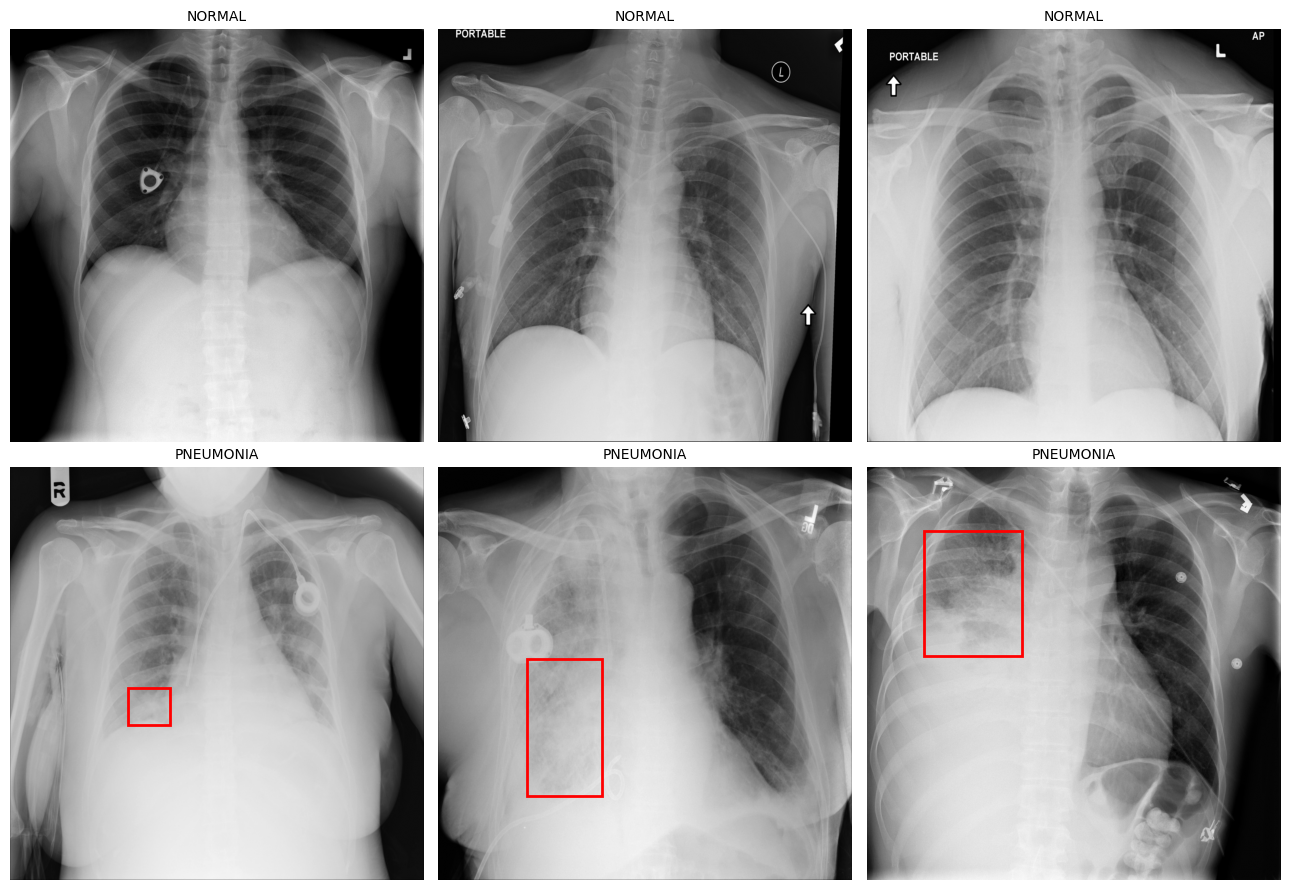

In [6]:
import matplotlib.patches as patches

def read_dicom(filepath):
    # Decode the DICOM file and return an eight bit grayscale array
    dcm = pydicom.dcmread(filepath)
    arr = dcm.pixel_array.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255.0
    return arr.astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for row_idx, label in enumerate(["NORMAL", "PNEUMONIA"]):
    sample = train_df[train_df["label"] == label].sample(3, random_state=SEED)
    for col_idx, (_, r) in enumerate(sample.iterrows()):
        arr = read_dicom(r["filepath"])
        ax = axes[row_idx, col_idx]
        ax.imshow(arr, cmap="gray")
        boxes = labels[(labels["patientId"] == r["patientId"]) & labels["x"].notna()]
        for _, b in boxes.iterrows():
            ax.add_patch(patches.Rectangle((b["x"], b["y"]), b["width"], b["height"],
                                           linewidth=2, edgecolor="red", facecolor="none"))
        ax.set_title(label, fontsize=10)
        ax.axis("off")
plt.tight_layout()
plt.show()

## Part 7. Preprocessing step five, transformations and augmentation from the SOTA papers

Resize to 224 by 224 follows the PLOS ONE 2024, MDPI 2025 and MedVAG papers of the SOTA table and matches the ImageNet pretraining resolution of ResNet50. Normalization uses the official ImageNet channel statistics required by the pretrained weights. The augmentation policy reproduces the exact parameters of the MDPI Information 2025 paper, rotation of fifteen degrees, horizontal flip, and zoom of twenty percent, applied on the training set only. The single channel DICOM image is replicated to three channels because the pretrained backbone expects RGB input.

In [7]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(15),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class RsnaDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = read_dicom(row["filepath"])
        img = Image.fromarray(arr).convert("RGB")
        return self.transform(img), torch.tensor(row["target"], dtype=torch.long)

BATCH_SIZE = 32
train_loader = DataLoader(RsnaDataset(train_df, train_transform), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(RsnaDataset(val_df, eval_transform), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(RsnaDataset(test_df, eval_transform), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)
print("Loaders ready. Batches per training epoch:", len(train_loader))

Loaders ready. Batches per training epoch: 326


## Part 8. Freeze the splits on disk

The three splits are written to CSV before any training so the exact partition is documented and reusable by every later notebook, which is a reproducibility deliverable of the project.

In [8]:
cols = ["patientId", "filepath", "class", "label", "target"]
train_df[cols].to_csv(os.path.join(OUTPUT_DIR, "rsna_train.csv"), index=False)
val_df[cols].to_csv(os.path.join(OUTPUT_DIR, "rsna_val.csv"), index=False)
test_df[cols].to_csv(os.path.join(OUTPUT_DIR, "rsna_test.csv"), index=False)
print("Splits saved")

Splits saved


## Part 9. Model, ResNet50 with transfer learning

The backbone is ResNet50 pretrained on ImageNet with its final layer replaced by a two class head, exactly the transfer learning setting of the MDPI Information 2025 baseline of the SOTA table. The loss is the cross entropy used by the Ensemble-CAM paper, with inverse frequency class weights to compensate the imbalance between normal and pneumonia images, the same motivation as the pos weight of the Scientific Reports 2025 paper. The optimizer is Adam with learning rate 1e-4, the value used by the Nature Machine Intelligence 2022 benchmark for fine tuning, since the 1e-3 of MDPI is suited to training a new head only while we fine tune the whole network. The scheduler ReduceLROnPlateau follows PLOS ONE 2024 and Ensemble-CAM.

In [9]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(DEVICE)

counts = train_df["target"].value_counts().sort_index().values
class_weights = torch.tensor(len(train_df) / (2.0 * counts), dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights.cpu().numpy().round(3))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                       factor=0.1, patience=2)
print("Trainable parameters in millions:",
      round(sum(p.numel() for p in model.parameters()) / 1e6, 1))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


Class weights: [0.84  1.236]
Trainable parameters in millions: 23.5


## Part 10. Training with early stopping

Early stopping monitors the validation AUC, the model selection practice of the PLOS ONE 2024 and Ensemble-CAM papers, with a patience of three epochs close to the patience values they report. The SOTA papers train up to fifty epochs on small datasets, but with fourteen thousand images convergence arrives within a few epochs, so ten epochs with early stopping respects both the literature and the weekly Kaggle GPU quota. The checkpoint with the best validation AUC is the one kept.

In [10]:
from sklearn.metrics import roc_auc_score

def run_epoch(loader, train_mode):
    # One pass over the loader, returns loss, labels and probabilities
    model.train() if train_mode else model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.set_grad_enabled(train_mode):
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(targets)
            all_labels.extend(targets.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy())
    return total_loss / len(loader.dataset), np.array(all_labels), np.array(all_probs)

EPOCHS = 50
PATIENCE = 8
CKPT = os.path.join(OUTPUT_DIR, "resnet50_rsna_best.pth")
best_auc, without_improvement = 0.0, 0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, _, _ = run_epoch(train_loader, True)
    val_loss, val_labels, val_probs = run_epoch(val_loader, False)
    val_auc = roc_auc_score(val_labels, val_probs)
    scheduler.step(val_auc)
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "val_loss": val_loss, "val_auc": val_auc})
    print(f"epoch {epoch}  train_loss {train_loss:.4f}  val_loss {val_loss:.4f}"
          f"  val_auc {val_auc:.4f}  minutes {round((time.time() - start) / 60, 1)}")
    if val_auc > best_auc:
        best_auc, without_improvement = val_auc, 0
        torch.save(model.state_dict(), CKPT)
        print("new best model saved")
    else:
        without_improvement += 1
        if without_improvement >= PATIENCE:
            print("early stopping")
            break

epoch 1  train_loss 0.2580  val_loss 0.1627  val_auc 0.9816  minutes 2.7
new best model saved
epoch 2  train_loss 0.1796  val_loss 0.1417  val_auc 0.9852  minutes 2.3
new best model saved
epoch 3  train_loss 0.1589  val_loss 0.1608  val_auc 0.9838  minutes 2.3
epoch 4  train_loss 0.1484  val_loss 0.1367  val_auc 0.9881  minutes 2.3
new best model saved
epoch 5  train_loss 0.1357  val_loss 0.1556  val_auc 0.9849  minutes 2.3
epoch 6  train_loss 0.1330  val_loss 0.1697  val_auc 0.9821  minutes 2.3
epoch 7  train_loss 0.1236  val_loss 0.1416  val_auc 0.9858  minutes 2.3
epoch 8  train_loss 0.0968  val_loss 0.1348  val_auc 0.9872  minutes 2.2
epoch 9  train_loss 0.0893  val_loss 0.1400  val_auc 0.9870  minutes 2.3
epoch 10  train_loss 0.0853  val_loss 0.1363  val_auc 0.9872  minutes 2.3
epoch 11  train_loss 0.0790  val_loss 0.1375  val_auc 0.9873  minutes 2.3
epoch 12  train_loss 0.0775  val_loss 0.1360  val_auc 0.9875  minutes 2.3
early stopping


## Part 11. Evaluation on the held out test set

The best checkpoint is reloaded and evaluated once on the untouched test split. The metric set is the one fixed in the experimental configuration of the project and used by the PLOS ONE 2024 paper, Accuracy, Precision, Recall, F1 and AUC. The references to situate the numbers are the MDPI 2025 ResNet50 baseline, Accuracy 0.90 and AUC 0.93 on a pediatric dataset, and the Ensemble-CAM classification accuracies between 0.93 and 0.98. Direct numerical comparison must stay careful since the datasets differ.

In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)

model.load_state_dict(torch.load(CKPT))
_, test_labels, test_probs = run_epoch(test_loader, False)
test_preds = (test_probs >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(test_labels, test_preds),
    "precision": precision_score(test_labels, test_preds),
    "recall": recall_score(test_labels, test_preds),
    "f1": f1_score(test_labels, test_preds),
    "auc": roc_auc_score(test_labels, test_probs)
}
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

with open(os.path.join(OUTPUT_DIR, "rsna_metrics.json"), "w") as f:
    json.dump({k: round(v, 4) for k, v in metrics.items()}, f, indent=2)

accuracy: 0.9448
precision: 0.9297
recall: 0.9343
f1: 0.9320
auc: 0.9868


## Part 12. Evaluation figures

Three figures document the run for the thesis. The training curves show convergence and the absence of severe overfitting. The confusion matrix details the error types, which matters clinically since a false negative is a missed pneumonia. The ROC curve visualizes the discrimination summarized by the AUC.

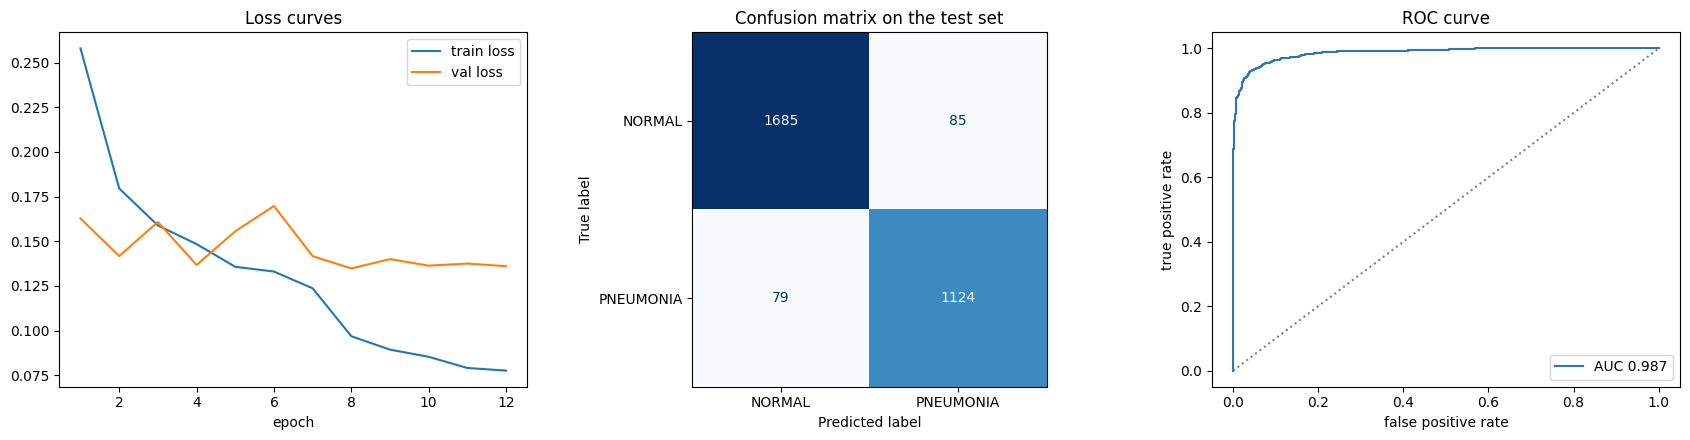

In [12]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(hist["epoch"], hist["train_loss"], label="train loss")
axes[0].plot(hist["epoch"], hist["val_loss"], label="val loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].set_title("Loss curves")

cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"]).plot(
    cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion matrix on the test set")

fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[2].plot(fpr, tpr, color="#2E75B6", label=f"AUC {metrics['auc']:.3f}")
axes[2].plot([0, 1], [0, 1], linestyle=":", color="gray")
axes[2].set_xlabel("false positive rate")
axes[2].set_ylabel("true positive rate")
axes[2].legend()
axes[2].set_title("ROC curve")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rsna_resnet50_evaluation.png"), dpi=200, bbox_inches="tight")
plt.show()

## Part 13. Save the per image predictions

The per image predictions are the input of the next notebook, where the CAM heatmaps of correctly and incorrectly classified images will be generated and evaluated against the expert boxes saved in part five. Commit this notebook with Save Version and Save and Run All, then create a Kaggle dataset from its output.

In [13]:
out = test_df[["patientId", "label", "target"]].copy()
out["prob_pneumonia"] = test_probs
out["prediction"] = test_preds
out.to_csv(os.path.join(OUTPUT_DIR, "rsna_test_predictions.csv"), index=False)

print("Final content of the working directory:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" ", f)

Final content of the working directory:
  __notebook__.ipynb
  resnet50_rsna_best.pth
  rsna_bboxes_eval.csv
  rsna_metrics.json
  rsna_resnet50_evaluation.png
  rsna_test.csv
  rsna_test_predictions.csv
  rsna_train.csv
  rsna_val.csv
